In [2]:
!pip install bertopic pythainlp pandas
!pip install -U sentence-transformers gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 75.9 MB/s eta 0:00:00


In [20]:
ASSETS = "./assets/"

In [22]:
import pandas as pd

df = pd.read_csv(f"{ASSETS}/postprocessed_output_with_classified.csv")
df = df.sort_values("id").drop_duplicates(subset=["id"], keep="first")
df.head()

,id,platform,platform_type,url,content_type,timestamp,scraper_module,text,scrape_date,source_file,tokens,pred_label,pred_score,prob_malexandersalazar/xlm-roberta-large-binary-cls-toxicity,pred_malexandersalazar/xlm-roberta-large-binary-cls-toxicity
0,1139881968735096832,twitter,post,https://x.com/9veW7NqOtKBYvCi/status/113988196...,text,2019-06-15T13:06:53.000Z,selenium_x_scraper_v1,รับวิจารณ์ควยนะค่ะ ตอบทุกคนค่ะ 1.รีทวิตโพสนี้ก...,2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,"['รับ', 'วิจารณ์', 'ควย', 'นะ', 'ค่ะ', 'ตอบ', ...",unsafe,0.873818,0.999991,1.0
1,1146471075519221761,twitter,post,https://x.com/manoww089/status/114647107551922...,text,2019-07-03T17:29:39.000Z,selenium_x_scraper_v1,กดรีทวีต ติดตาม รอกันเลย ค่า,2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,"['กด', 'รี', 'ทวีต', 'ติดตาม', 'รอ', 'กัน', 'เ...",safe,0.941913,0.002729,0.0
2,1155762265791971328,twitter,post,https://x.com/87T7eNTKwWlNMmz/status/115576226...,text,2019-07-29T08:49:31.000Z,selenium_x_scraper_v1,สาวน่ารัก สาวน่าเย็ด ชักว่าว ชักว่าวใส่รูป เงี...,2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,"['สาว', 'น่ารัก', 'สาว', 'น่า', 'เย็ด', 'ชักว่...",unsafe,0.983231,0.999986,1.0
3,1164576110081761280,twitter,post,https://x.com/87T7eNTKwWlNMmz/status/116457611...,text,2019-08-22T16:32:36.000Z,selenium_x_scraper_v1,ชอบวะคุก็ยอม สาวน่ารัก สาวน่าเย็ด ชักว่าว ชักว...,2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,"['ชอบ', 'วะ', 'คุ', 'ก็', 'ยอม', 'สาว', 'น่ารั...",unsafe,0.980390,0.999993,1.0
4,1210516789781651460,twitter,post,https://x.com/SUNTI_1581_/status/1210516789781...,text,2019-12-27T11:04:27.000Z,selenium_x_scraper_v1,น้องกระต่ายงานโคตรดี,2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,"['น้อง', 'กระต่าย', 'งาน', 'โคตร', 'ดี']",unsafe,0.583234,0.990853,1.0


In [23]:
model = "new5558/simcse-model-wangchanberta-base-att-spm-uncased"

In [25]:
import numpy as np

embedded_path = f'{ASSETS}/postprocessed_embeddings/{model.replace("/","_")}.npy'
# 1. Save to a .npy file (Binary format: fast and preserves precision)
# np.save(embedded_path, embeddings)

# 2. Load it back later
loaded_embeddings = np.load(embedded_path)

# # Verify it looks the same
print(loaded_embeddings)

[[ 0.11058958 -0.03223726 -1.7584467  ...  0.07847606 -0.42223322
  -0.9791442 ]
 [ 0.35227278  0.28797308  2.0000193  ...  0.2800569   0.1427126
  -0.17260137]
 [ 0.51662266 -1.8995267  -1.2067847  ... -1.1720523  -0.7771739
  -0.45144835]
 ...
 [-0.83795244  0.98140657 -1.6019189  ... -0.6267883  -1.3713913
  -0.05497512]
 [ 0.833063   -0.3133333   0.07126226 ... -0.01415623 -1.3154367
  -0.93909806]
 [ 0.49209893  1.3230155   0.23094386 ... -0.74571544 -0.3430819
  -0.12054368]]


In [53]:
def passthrough_tokenizer(text):
    return text.split()

from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(
    tokenizer=passthrough_tokenizer,  # <-- IMPORTANT
    token_pattern=None,               # <-- MUST disable regex
    lowercase=False,
    stop_words=None,                  # <-- อย่าใช้ thai_stopwords
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),               # เพราะคุณ tokenize แล้ว → ใช้ได้ดี
)

In [ ]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

# --------------------------
# 1. UMAP configuration
# --------------------------
umap_model = UMAP(
    n_neighbors=35,        # more neighbors = more stable clusters
    n_components=10,       # richer embedding space
    min_dist=0.0,          # encourages tight clusters
    metric="cosine",
    random_state=42
)

# --------------------------
# 2. HDBSCAN configuration
# --------------------------
hdbscan_model = HDBSCAN(
    min_cluster_size=25,   # avoids tiny garbage topics
    min_samples=5,         # controls density sensitivity
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# --------------------------
# 3. Topic Model init
# --------------------------
topic_model = BERTopic(
    language=None,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    verbose=True
)

2025-12-11 03:01:21,742 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-11 03:03:00,122 - BERTopic - Dimensionality - Completed ✓
2025-12-11 03:03:00,125 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-11 03:05:28,626 - BERTopic - Cluster - Completed ✓
2025-12-11 03:05:28,639 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-11 03:05:30,429 - BERTopic - Representation - Completed ✓


# Visualization


In [18]:
from bertopic import BERTopic
topic_model = BERTopic.load(f"{DEFAULT_PATH}/my_bertopic_model_{ENCODER}")

In [55]:
# 6. View Results
topic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,18917,-1_ไม่_ที่_ก็_มี,"[ไม่, ที่, ก็, มี, ได้, คน, มัน, แบ, จะ, เป็น]",[หลง เข้า ไปดู นาง ขึ้น ไลฟ์ อยู่ อยาก จะ บอ ก...
1,0,738,0_ชาย แท้_แท้_ชาย_ว่า ชาย,"[ชาย แท้, แท้, ชาย, ว่า ชาย, คำ, คำ ว่า, คำด่า...","[ชาย แท้ วะ, ชาย แท้, ชาย แท้]"
2,1,579,1_เดิน_แซง_กลัว_ระแวง,"[เดิน, แซง, กลัว, ระแวง, รีบ, วิน, เดินตาม, วิ...",[นี่ เลิกงาน ดึก เดิน กลับ ้าน วัน ั้น มี ผู้ช...
3,2,568,2_เร ด_เร_ด_จัน,"[เร ด, เร, ด, จัน, จัน เร, จาร, จาร เร, จารย์,...","[จัน เร ด มา แล้ว, ของจริง จัน เร ด, รัก นะคะ ..."
4,3,417,3_หัวเราะ_หัวเราะ หัวเราะ_หัวเราะ จริง_หัวเราะ ะา,"[หัวเราะ, หัวเราะ หัวเราะ, หัวเราะ จริง, หัวเร...","[หัวเราะ ะา, หัวเราะ จริง, ห๋า หัวเราะ]"


In [ ]:
# 1. Add the Topic ID back to your original DataFrame
df['topic'] = topics

# 2. Add the Top Keywords for that topic to the DataFrame (Optional, but helpful)
# This creates a dictionary map: {0: "drug_health_hospital", 1: "bank_money_stock"...}
topic_labels = topic_model.get_topic_info().set_index('Topic')['Name'].to_dict()
df['topic_name'] = df['topic'].map(topic_labels)

Files saved successfully!


In [19]:
topic_model.visualize_topics()

In [16]:
topic_model.visualize_hierarchy()

In [17]:
topic_model.visualize_barchart()

In [21]:
topic_model.visualize_distribution(probs[0])

In [22]:
gender_ids = [0, 5, 18, 19, 25, 27, 33, 36, 38, 40, 43, 70, 81, 115, 122, 146, 150, 169]

df_gender = df[df["topic"].isin(gender_ids)]
docs_gender = df_gender["text"].tolist()

In [34]:
from umap import UMAP
import numpy as np
import pandas as pd

# 2D UMAP for plotting
umap_2d = UMAP(
    n_neighbors=35,
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

embedding_2d = umap_2d.fit_transform(embeddings)

df_plot = pd.DataFrame({
    "x": embedding_2d[:, 0],
    "y": embedding_2d[:, 1],
    "topic": topics,
    "text": raw_text_list
})

In [38]:
df_plot = df_plot[df_plot["topic"] != -1]

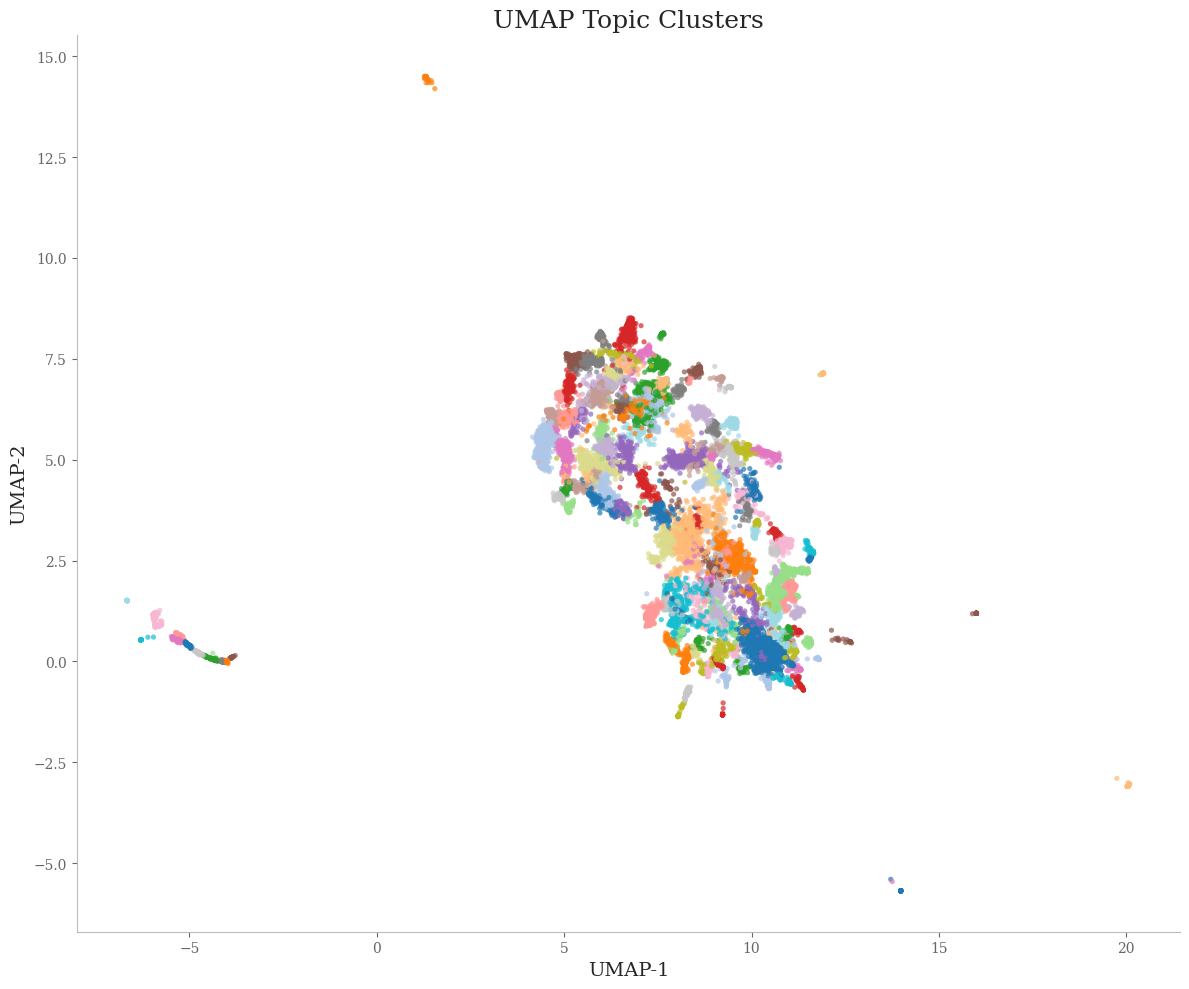

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# Global Styling (Your Style)
# ---------------------------------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["DejaVu Serif"]
plt.rcParams["axes.edgecolor"] = "#BBBBBB"
plt.rcParams["axes.labelcolor"] = "#252525"
plt.rcParams["xtick.color"] = "#666666"
plt.rcParams["ytick.color"] = "#666666"
plt.rcParams["text.color"] = "#252525"

# ---------------------------------------------------
# Plot
# ---------------------------------------------------
plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=df_plot,
    x="x",
    y="y",
    hue="topic",
    palette="tab20",     # functional, not aesthetic
    s=14,                # small points for dense clusters
    alpha=0.7,
    linewidth=0,
    legend=False         # ❗ important for 100+ topics
)

plt.title("UMAP Topic Clusters", fontsize=18)
plt.xlabel("UMAP-1", fontsize=14)
plt.ylabel("UMAP-2", fontsize=14)

# Minimalist axes
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)

plt.tight_layout()
plt.show()

In [77]:
gender_identity = [0, 5, 18, 19, 25, 27, 33, 36, 38, 40, 43, 70, 81, 115, 122, 146, 150, 169]
sexual_language = [15, 42, 100, 114, 148, 161]
role_stereotypes_norm = [17, 33, 36, 38, 169, 170]
neutral:list[int] = [-1, 71, 74, 110, 140]
emotion = [1, 6, 12, 16, 22, 23, 50, 62, 68, 76, 77, 79, 82, 83, 97, 107, 112, 117, 126, 130, 131, 163, 175]
toxic_language = [3, 9, 14, 22, 24, 46, 51, 63, 77, 106, 111, 114, 133, 137, 154, 172, 173, 144]
mv = [8, 10, 11, 12, 13, 29, 31, 37, 41, 50, 57, 59, 60, 66, 68, 72, 87, 91, 93, 94, 98, 105, 107, 109, 119, 134, 139, 149, 162, 175]
apperance = [33, 35, 42, 87, 94, 146]
norms_non_gender = [17, 48, 96, 170]
crime_violence_legal = [
    30,   # ยิง–ปืน
    89,   # สงคราม–ทหาร
    106,  # ลิง/เลือด
    108,  # ต่อย-เด็ก
    111,  # สังคมเหี้ย ๆ
    115,  # ผู้หญิงเดิน-กลัว
    137,  # สอบสวน–ตำรวจ
    154   # กระทืบ–คดี
]
meta_society_opinion = [
    39, 44, 56, 63, 65, 70, 73, 92,
    97, 110, 111, 115, 129, 136,
    138, 143, 164
]

# -------------------------------
# GROUP 10 — Miscellaneous / Other Themes
# -------------------------------

technology_tools = [7, 58, 113]
food = [151]
commercial_marketing = [165]
clothing_style = [157, 161]
locations = [143]
misc_reactions = [90, 75, 124]

In [64]:
topic_info = topic_model.get_topic_info()

topic_name_map = dict(zip(topic_info["Topic"], topic_info["Name"]))

In [78]:
def show_topic_names(topic_ids: list[int], title: str):
    print(f"\n{title}")
    print("-" * len(title))
    for tid in sorted(set(topic_ids)):
        name = topic_name_map.get(tid, "UNKNOWN")
        print(f"{tid:>4} : {name}")

In [79]:
show_topic_names(gender_identity, "Gender Identity")
# show_topic_names(sexual_language, "Sexual Language")
# show_topic_names(role_stereotypes_norm, "Role Stereotypes / Normative")
# show_topic_names(neutral, "Neutral")
# show_topic_names(emotion, "Emotion")
# show_topic_names(toxic_language, "Toxic Language")
# show_topic_names(mv, "Mixed / MV")
# show_topic_names(appearance, "Appearance")
# show_topic_names(norms_non_gender, "Non-Gender Norms")

# show_topic_names(crime_violence_legal, "GROUP 8 — Crime / Violence / Legal")
# show_topic_names(meta_society_opinion, "GROUP 9 — Meta / Society / Opinion")

# show_topic_names(technology_tools, "Technology / Tools")
# show_topic_names(food, "Food")
# show_topic_names(commercial_marketing, "Commercial / Marketing")
# show_topic_names(clothing_style, "Clothing / Style")
# show_topic_names(locations, "Locations")
# show_topic_names(misc_reactions, "Misc Reactions")


Gender Identity
---------------
   0 : 0_เพราะ มาก_อุ_มาก_จิง
   5 : 5_ร้องไห้_น้ำตาไหล_ฟัง_ร้องไห้ เลย
  18 : 18_กระ เท_กระ_เท ย_เท
  19 : 19_ริ ส_ค ริ_ริ_เฮีย
  25 : 25_โป๊_แต่งตัว_แต่งตัว โป๊_ใน ที่สาธารณะ
  27 : 27_ความเท่าเทียม_เท่าเทียม_เพศ_เหยียด
  33 : 33_ขอบคุณ_พี่_พี่ นัท_ริ ป
  36 : 36_10_16_10 10_21
  38 : 38_ยัง ฟัง_ฟัง อยู่_2019_ฟัง
  40 : 40_ผู้หญิง_ผู้ชาย_กะเทย_ชอบ ผู้ชาย
  43 : 43_ยา_ถุงยาง_ปาร์ตี้_ยาเสพติด
  70 : 70_คนอื่น_ยุ่ง_เสือก_เขา
  81 : 81_น่ารัก_น่ารัก อ่ะ_ค่ะ น่ารัก_น่ารัก มาก
 115 : 115_นัท สวย_สวย มาก_สวย_นัท
 122 : 122_ปิด_ปิด จ๊อบ_จ๊อบ_fastwork
 146 : 146_เพลง_เพลง นี้_ชอบ เพลง_mv
 150 : 150_จริง หัวเราะ_หัวเราะ จริง_เศร้า_ตรง ค่ะ
 169 : UNKNOWN


In [65]:
df_plot["topic_name"] = df_plot["topic"].map(topic_name_map)

In [66]:
df_gender = df_plot[df_plot["topic"].isin(gender_identity)]

In [67]:
centroids = df_gender.groupby("topic")[["x", "y"]].mean()

In [68]:
!wget -q https://github.com/google/fonts/raw/main/ofl/kanit/Kanit-Regular.ttf
!wget -q https://github.com/google/fonts/raw/main/ofl/kanit/Kanit-Bold.ttf

In [69]:
import matplotlib.font_manager as fm

kanit_font = fm.FontProperties(fname="Kanit-Regular.ttf")
kanit_font_bold = fm.FontProperties(fname="Kanit-Bold.ttf")

In [70]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["DejaVu Serif"]  # English / numbers
plt.rcParams["axes.labelcolor"] = "#252525"
plt.rcParams["xtick.color"] = "#252525"
plt.rcParams["ytick.color"] = "#252525"
plt.rcParams["text.color"] = "#252525"

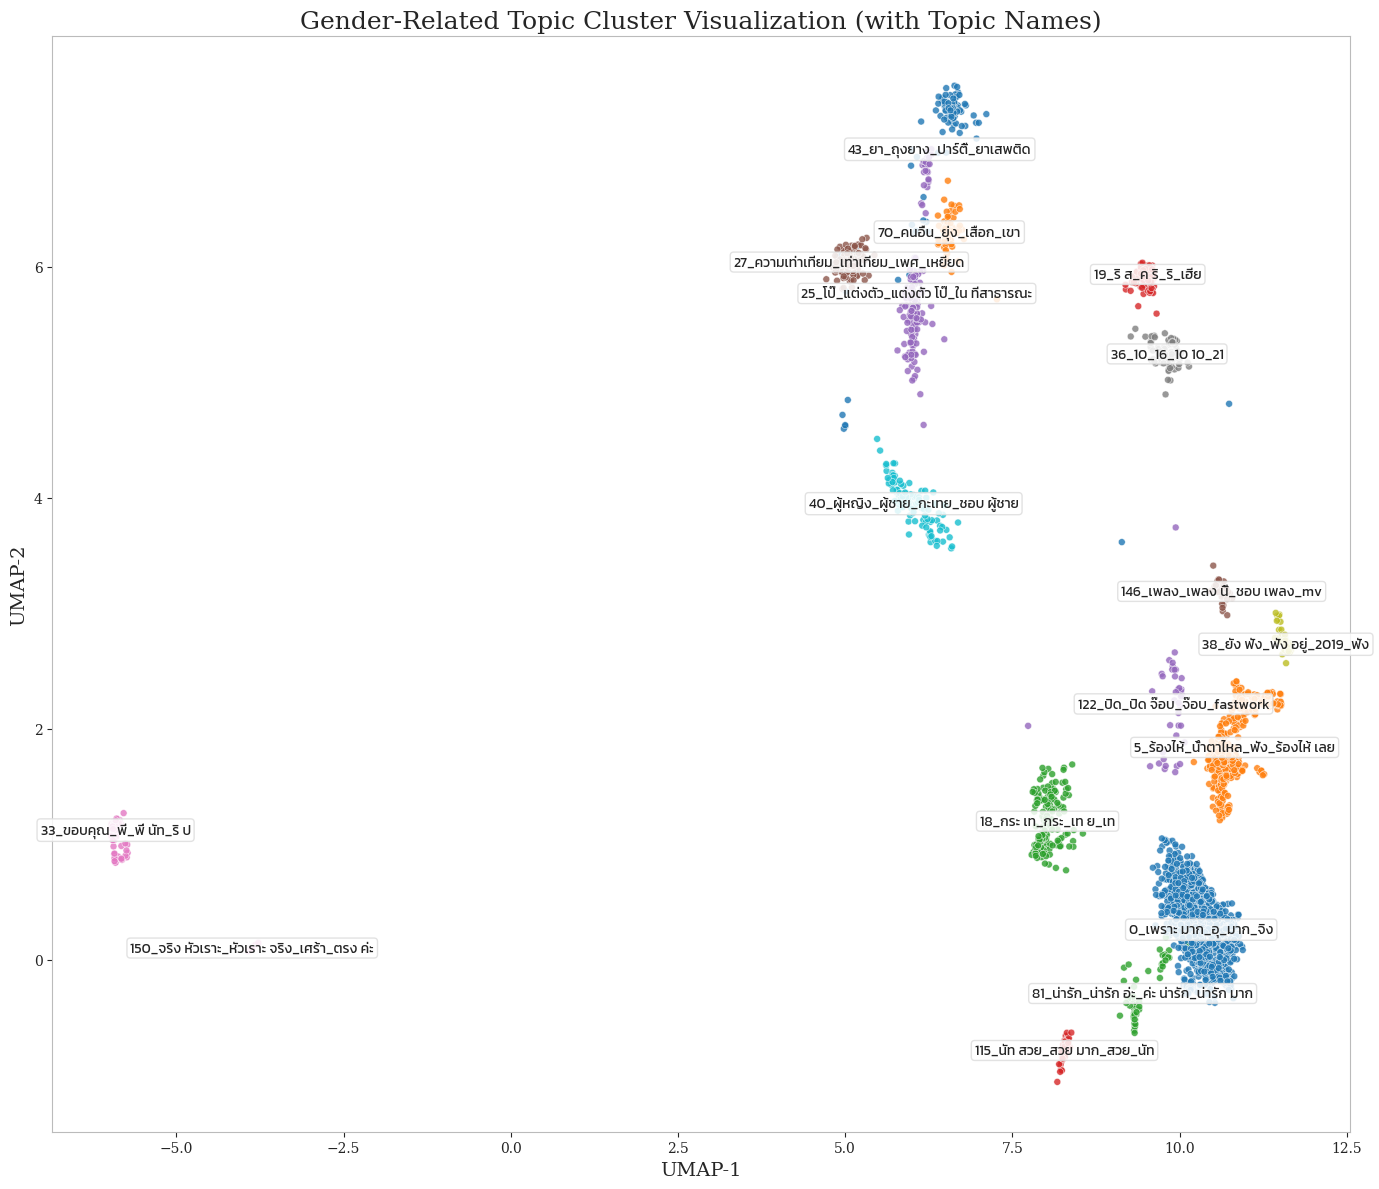

In [71]:
plt.figure(figsize=(14, 12))

sns.scatterplot(
    data=df_gender,
    x="x", y="y",
    hue="topic",
    palette="tab10",
    s=25,
    alpha=0.8,
    legend=False
)

# Thai font for cluster labels
for topic_id, row in centroids.iterrows():
    name = topic_name_map.get(topic_id, f"Topic {topic_id}")

    plt.text(
        row["x"], row["y"],
        name,
        fontsize=10,
        ha="center",
        va="center",
        fontproperties=kanit_font,
        bbox=dict(
            facecolor="white",
            edgecolor="#DDDDDD",
            alpha=0.85,
            boxstyle="round,pad=0.25"
        )
    )

# English title + axis labels
plt.title(
    "Gender-Related Topic Cluster Visualization (with Topic Names)",
    fontsize=18
)
plt.xlabel("UMAP-1", fontsize=14)
plt.ylabel("UMAP-2", fontsize=14)

plt.tight_layout()
plt.show()

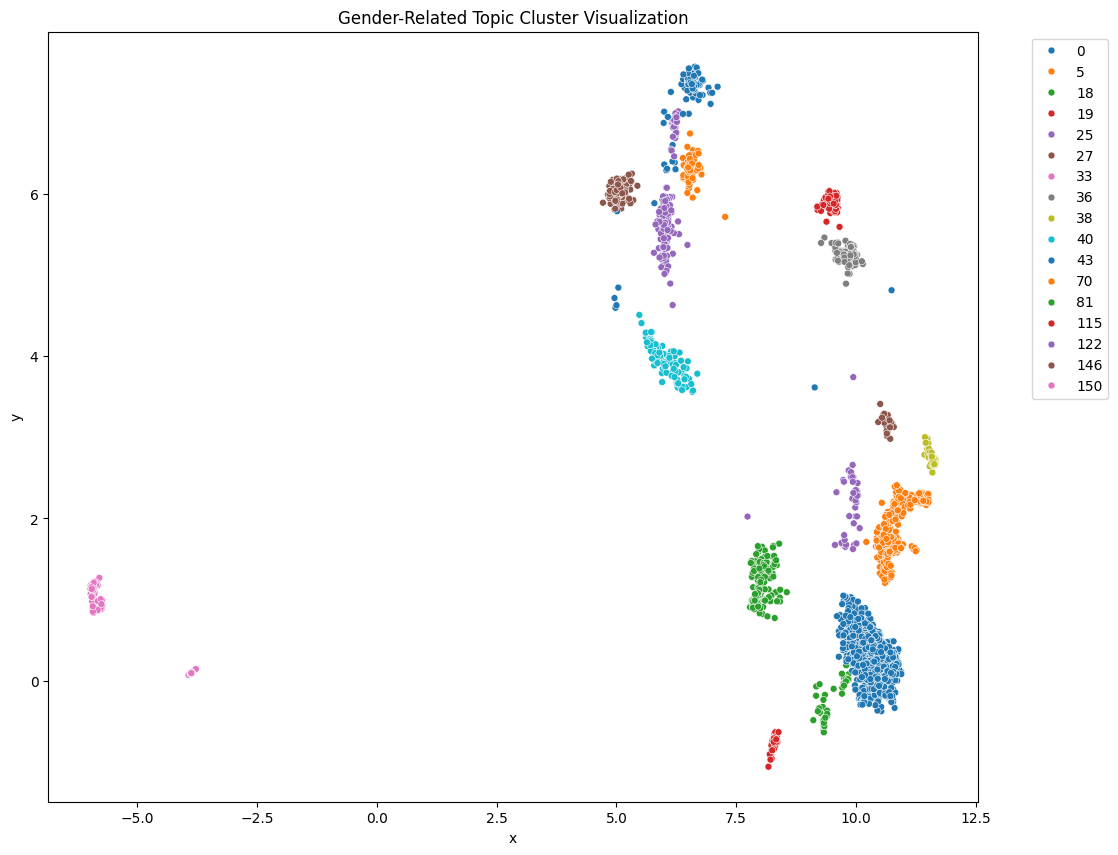

In [37]:
df_gender = df_plot[df_plot["topic"].isin(gender_group)]

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_gender,
    x="x", y="y",
    hue="topic",
    palette="tab10",
    s=25
)

plt.title("Gender-Related Topic Cluster Visualization")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()